In [13]:
import polars as pl
import plotly.express as px
import plotly.graph_objects as go
# import pandas as pd
# pd.set_option('display.max_columns', None)
# pl.Config.set_tbl_rows(-1)
path = "/home/jovyan/work/data/bronze/Polars/"

In [2]:
!ls $pathhttp://127.0.0.1:8888/lab?token=3bb5d8979f3220fac6a06cc93a06fcf15fbbdbff249e7f89


complete_fraud_data.parquet


In [10]:
fraud_data_df = pl.scan_parquet(f"{path}complete_fraud_data.parquet")
fraud_data_df.show(5)

id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,merchant_latitude,merchant_longitude,mcc_description,current_age,retirement_age,birth_year,birth_month,gender,address,client_latitude,client_longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web,target
str,datetime[μs],str,str,f64,cat,i64,str,str,str,str,cat,f64,f64,str,i64,i64,i64,i64,cat,str,f64,f64,f64,f64,f64,i64,i64,cat,cat,str,date,str,bool,i64,f64,date,i64,bool,bool
"""7475645""",2010-01-01 06:20:00,"""1843""","""4553""",3.11,"""Swipe Transaction""",79664,"""Manteno""","""IL""","""60950""","""5814""",null,41.2514,-87.8468,"""Fast Food Restaurants""",89,73,1930,11,"""Male""","""89 Wessex Street""",41.5,-87.63,16503.0,38761.0,69.0,760,7,"""Mastercard""","""Debit""","""5813126802246388""",2022-12-01,"""390""",true,2,10638.0,2004-09-01,2010,false,false
"""7475373""",2010-01-01 01:11:00,"""1642""","""4281""",3.96,"""Swipe Transaction""",44625,"""Manasquan""","""NJ""","""08736""","""5812""",null,40.1217,-74.0611,"""Eating Places and Restaurants""",37,66,1982,4,"""Female""","""48190 Plum Drive""",39.96,-74.06,19848.0,40470.0,41938.0,731,5,"""Visa""","""Debit""","""4680328184934192""",2012-12-01,"""377""",true,1,26730.0,2008-08-01,2010,false,null
"""7475471""",2010-01-01 03:27:00,"""1209""","""3387""",4.78,"""Swipe Transaction""",50783,"""New Rochelle""","""NY""","""10801""","""5411""",null,40.9166,-73.7877,"""Grocery Stores, Supermarkets""",45,67,1974,6,"""Female""","""95 12th Drive""",40.94,-73.86,31299.0,63815.0,4832.0,699,6,"""Mastercard""","""Debit (Prepaid)""","""5771648554583821""",2020-08-01,"""775""",true,1,76.0,2008-06-01,2014,false,false
"""7475432""",2010-01-01 02:25:00,"""1214""","""5508""",51.58,"""Online Transaction""",98436,"""ONLINE""",null,null,"""5192""",null,null,null,"""Books, Periodicals, Newspapers""",40,64,1979,11,"""Male""","""83302 Valley Stream Lane""",42.06,-71.24,35544.0,72470.0,133421.0,711,2,"""Visa""","""Debit""","""4968168260037253""",2021-05-01,"""607""",true,1,21073.0,2007-11-01,2011,false,false
"""7475819""",2010-01-01 07:08:00,"""511""","""1038""",21.5,"""Swipe Transaction""",79038,"""Phoenix""","""AZ""","""85015""","""7538""",null,33.5082,-112.1011,"""Automotive Service Shops""",66,68,1953,10,"""Male""","""153 Tenth Lane""",32.21,-110.88,17460.0,35602.0,55369.0,661,5,"""Visa""","""Credit""","""4150093118072730""",2022-06-01,"""135""",true,2,6100.0,2004-02-01,2009,false,false


In [4]:
fraud_data_df.collect_schema()

Schema([('id', String),
        ('date', Datetime(time_unit='us', time_zone=None)),
        ('client_id', String),
        ('card_id', String),
        ('amount', Float64),
        ('use_chip', Categorical),
        ('merchant_id', Int64),
        ('merchant_city', String),
        ('merchant_state', String),
        ('zip', String),
        ('mcc', String),
        ('errors', Categorical),
        ('merchant_latitude', Float64),
        ('merchant_longitude', Float64),
        ('mcc_description', String),
        ('current_age', Int64),
        ('retirement_age', Int64),
        ('birth_year', Int64),
        ('birth_month', Int64),
        ('gender', Categorical),
        ('address', String),
        ('client_latitude', Float64),
        ('client_longitude', Float64),
        ('per_capita_income', Float64),
        ('yearly_income', Float64),
        ('total_debt', Float64),
        ('credit_score', Int64),
        ('num_credit_cards', Int64),
        ('card_brand', Categorical),
   

In [7]:
fraud_data_df.collect().select(pl.all().count())

id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,errors,mcc_description,target,current_age,retirement_age,birth_year,birth_month,gender,client_latitude,client_longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
13305915,13305915,13305915,13305915,13305915,13305915,13305915,13305915,11742215,11653209,211393,13305915,8914963,13305915,13305915,13305915,13305915,13305915,13305915,13305915,13305915,13305915,13305915,13305915,13305915,13305915,13305915,13305915,13305915,13305915,13305915,13305915,13305915,13305915,13305915,13305915


In [15]:
fraud_data_df.select(pl.all().n_unique()).collect().unpivot().sort("value", descending=True)

variable,value
str,u32
"""id""",13305915
"""date""",4136496
"""amount""",81160
"""merchant_id""",74831
"""zip""",25257
"""merchant_longitude""",23890
"""merchant_latitude""",22893
"""merchant_city""",12492
"""card_id""",4071


In [4]:
fraud_data_df = (
    fraud_data_df
    .drop(
        ["id", "card_number", "cvv", "card_on_dark_web"],
        strict=False
    )
)

fraud_data_df.limit(5).collect()

date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,errors,mcc_description,target,current_age,retirement_age,birth_year,birth_month,gender,client_latitude,client_longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,card_brand,card_type,expires,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed
datetime[μs],str,str,f64,cat,i64,str,cat,str,cat,str,bool,i64,i64,i64,i64,cat,f64,f64,f64,f64,f64,i64,i64,cat,cat,date,bool,i64,f64,date,i64
2010-01-01 00:34:00,"""394""","""4717""",26.04,"""Online Transaction""",39021,"""ONLINE""",null,null,null,"""Tolls and Bridge Fees""",false,52,71,1967,4,"""Male""",41.09,-73.55,34138.0,69604.0,47193.0,684,4,"""Mastercard""","""Debit""",2023-06-01,true,1,23310.0,2009-09-01,2009
2010-01-01 00:02:00,"""561""","""4575""",14.57,"""Swipe Transaction""",67570,"""Bettendorf""","""IA""","""52722""",null,"""Department Stores""",false,48,67,1971,6,"""Male""",40.8,-91.12,18076.0,36853.0,112139.0,834,5,"""Mastercard""","""Credit""",2024-12-01,true,1,9100.0,2005-09-01,2015
2010-01-01 07:48:00,"""394""","""4717""",0.95,"""Swipe Transaction""",79463,"""Stamford""","""CT""","""06906""",null,"""Grocery Stores, Supermarkets""",null,52,71,1967,4,"""Male""",41.09,-73.55,34138.0,69604.0,47193.0,684,4,"""Mastercard""","""Debit""",2023-06-01,true,1,23310.0,2009-09-01,2009
2010-01-01 02:11:00,"""34""","""1166""",4.07,"""Swipe Transaction""",49789,"""Sacramento""","""CA""","""95829""",null,"""Service Stations""",false,41,55,1978,8,"""Male""",38.48,-121.34,25431.0,51854.0,72162.0,737,2,"""Mastercard""","""Debit""",2023-11-01,true,2,10775.0,2009-02-01,2010
2010-01-01 02:59:00,"""474""","""2493""",115.37,"""Swipe Transaction""",98648,"""Williston Park""","""NY""","""11596""",null,"""Fast Food Restaurants""",null,55,66,1964,4,"""Male""",40.75,-73.64,39705.0,80957.0,161166.0,683,6,"""Visa""","""Credit""",2015-04-01,true,1,16900.0,2005-04-01,2014


In [125]:
client_fraudlabel_df = (
    fraud_data_df
    .select("client_id", "target")
    .group_by("client_id")
    .agg(
         pl.col("target").any().alias("Total")
    )
    .with_columns(
        pl.when(pl.col("Total") > 0).then(pl.lit("Fraudulent_Client")).otherwise(pl.lit("Legitimate_Client"))
        .alias("client_label")
    )
)

client_fraudlabel_df.limit(5).collect()

client_id,Total,client_label
str,bool,str
"""1123""",true,"""Fraudulent_Client"""
"""123""",true,"""Fraudulent_Client"""
"""55""",true,"""Fraudulent_Client"""
"""906""",false,"""Legitimate_Client"""
"""146""",true,"""Fraudulent_Client"""


In [96]:
(
    client_fraudlabel_df
    .select(
        pl.col("client_label").value_counts(name="Total")
    )
    .collect()
)

client_label
struct[2]
"{""Legitimate_Client"",23}"
"{""Fraudulent_Client"",1196}"


In [95]:
(
    client_fraudlabel_df
    .select(
        pl.col("client_label").value_counts(name="Total")
    )
    .collect()
    .unnest("client_label")
)

client_label,Total
str,u32
"""Legitimate_Client""",23
"""Fraudulent_Client""",1196


In [35]:
demographic_df = (
    pl.scan_parquet("/home/jovyan/work/data/silver/users_data_df.parquet")
    .select(["current_age", "gender"])
    .group_by("current_age", "gender")
    .len(name="Total")
    .with_columns( 
        pl.when(pl.col("gender") == "Male").then(pl.col("Total") * -1).otherwise(pl.col("Total")).alias("count_pyramid")
    )
    .sort("Total", descending=True)
    # .sort(pl.col("count_pyramid").abs(), descending=True)    
)

demographic_df.limit(5).collect()

current_age,gender,Total,count_pyramid
i32,str,u32,i64
18,"""Male""",43,-43
18,"""Female""",34,34
30,"""Male""",28,-28
49,"""Female""",27,27
48,"""Male""",26,-26


In [33]:
demographic_first_fraud_age_df = (
    fraud_data_df
    .filter(pl.col("target")) 
    .group_by("client_id", "gender")
    .agg(
        age_at_first_fraud = pl.col("date").dt.year().min() - pl.col("birth_year").first()
    )
    .select("age_at_first_fraud", "gender")
    .group_by("age_at_first_fraud", "gender")
    .len(name = "Total")
    .with_columns(
        pl.when(pl.col("gender") == "Male")
            .then(pl.col("Total") * -1)
            .otherwise(pl.col("Total"))
            .alias("count_pyramid")
    )
    .sort("Total", descending=True)
)

demographic_first_fraud_age_df.show(10)

age_at_first_fraud,gender,Total,count_pyramid
i64,cat,u32,i64
43,"""Male""",25,-25
36,"""Female""",20,20
40,"""Female""",19,19
49,"""Female""",19,19
51,"""Male""",19,-19
54,"""Female""",18,18
46,"""Female""",18,18
41,"""Female""",18,18
33,"""Male""",18,-18


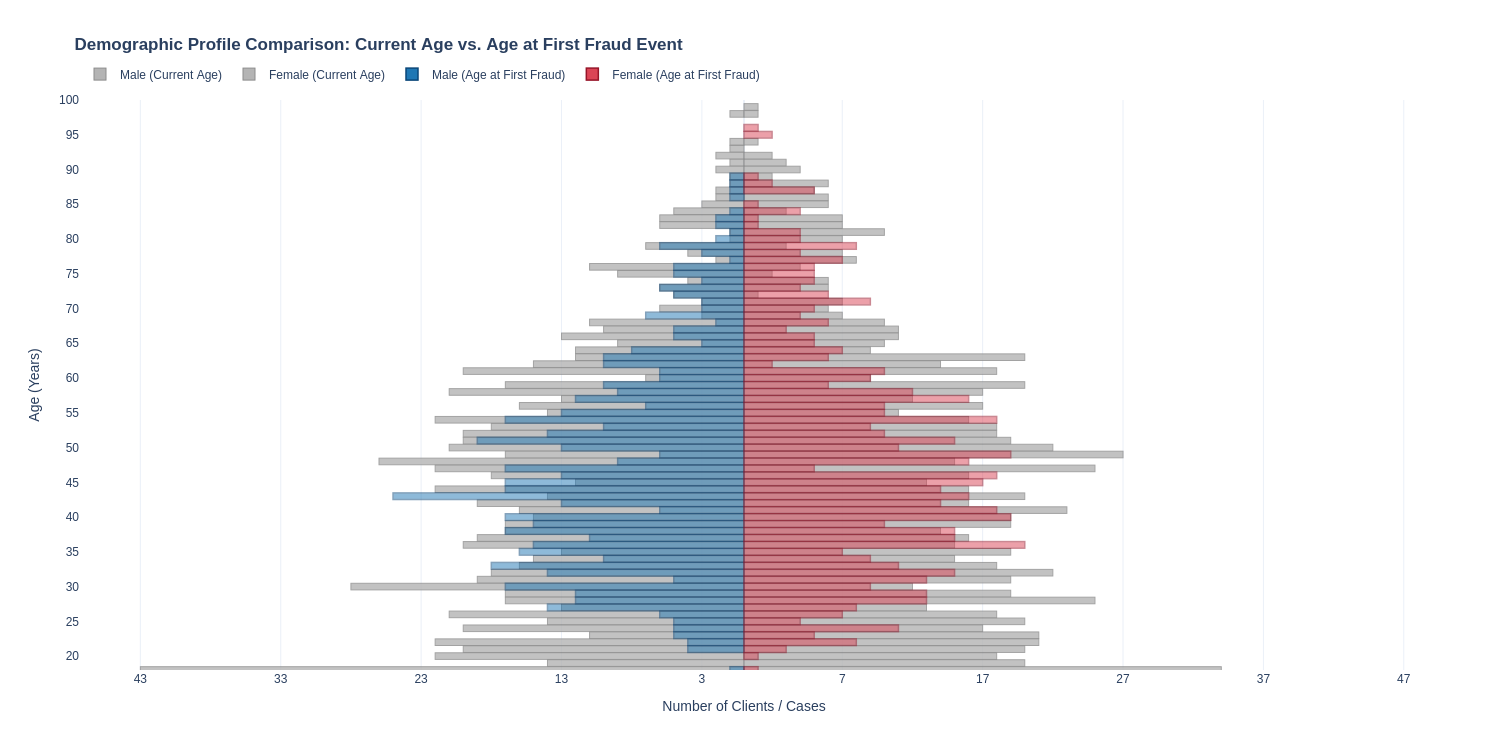

In [38]:
demo_mem = demographic_df.collect()
males_gen = demo_mem.filter(pl.col("gender") == "Male")
females_gen = demo_mem.filter(pl.col("gender") == "Female")

demo_first_mem = demographic_first_fraud_age_df.collect()
males_frd = demo_first_mem.filter(pl.col("gender") == "Male")
females_frd = demo_first_mem.filter(pl.col("gender") == "Female")

demographic_fig = go.Figure()

demographic_fig.add_trace(go.Bar(
    y=males_gen["current_age"],
    x=males_gen["count_pyramid"],
    name="Male (Current Age)",
    orientation="h",
    marker=dict(color="#B4B4B4", opacity=0.8, line=dict(color="#8C8C8C", width=1)),
    hovertemplate="<b>Age: %{y} years old</b><br>General Males: %{customdata:,}<extra></extra>",
    customdata=males_gen["Total"]
))
demographic_fig.add_trace(go.Bar(
    y=females_gen["current_age"],
    x=females_gen["count_pyramid"],
    name="Female (Current Age)",
    orientation="h",
    marker=dict(color="#B4B4B4", opacity=0.8, line=dict(color="#8C8C8C", width=1)),
    hovertemplate="<b>Age: %{y} years old</b><br>General Females: %{x:,}<extra></extra>"
))

demographic_fig.add_trace(go.Bar(
    y=males_frd["age_at_first_fraud"],
    x=males_frd["count_pyramid"],
    name="Male (Age at First Fraud)",
    orientation="h",
    marker=dict(color="#1F77B4", opacity=0.5, line=dict(color="#0A4678", width=1.5)),
    hovertemplate="<b>Age: %{y} years old</b><br>Fraudulent Males: %{customdata:,}<extra></extra>",
    customdata=males_frd["Total"]
))
demographic_fig.add_trace(go.Bar(
    y=females_frd["age_at_first_fraud"],
    x=females_frd["count_pyramid"],
    name="Female (Age at First Fraud)",
    orientation="h",
    marker=dict(color="#DB4455", opacity=0.5, line=dict(color="#961428", width=1.5)),
    hovertemplate="<b>Age: %{y} years old</b><br>Fraudulent Females: %{x:,}<extra></extra>"
))

max_count = int(max(demo_mem["Total"].max(), demo_first_mem["Total"].max()))
tick_step = max(1, max_count // 4)
tick_vals = list(range(-max_count - tick_step, max_count + tick_step, tick_step))
tick_text = [str(abs(v)) for v in tick_vals]

demographic_fig.update_layout(
    title="<b>Demographic Profile Comparison: Current Age vs. Age at First Fraud Event</b>",
    barmode="overlay",        
    bargap=0.05, height=750, width=950, autosize=False,    
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
    xaxis=dict(
        title="Number of Clients / Cases", 
        tickvals=tick_vals, ticktext=tick_text, range=[-max_count * 1.1, max_count * 1.1]
    ),
    yaxis=dict(title="Age (Years)", type="linear", range=[18, 100], dtick=5),
    template="plotly_white"
)

demographic_fig.show()

In [63]:
demographic_fraud_age_df = (
    fraud_data_df
    .select(["gender", "target", "date", "birth_year"])
    .filter(pl.col("target"))
    .with_columns(
        age_at_transaction = pl.col("date").dt.year() - pl.col("birth_year")
    )
    .group_by(["gender", "age_at_transaction"])
    .len("Total")
    .with_columns(
        Total_pyramid = pl.when(pl.col("gender") == "Male").then(pl.col("Total") * -1).otherwise(pl.col("Total"))
    )
)

demographic_fraud_age_df.show(5)

gender,age_at_transaction,Total,Total_pyramid
cat,i64,u32,i64
"""Female""",76,73,73
"""Female""",48,217,217
"""Male""",35,151,-151
"""Female""",77,106,106
"""Female""",47,101,101


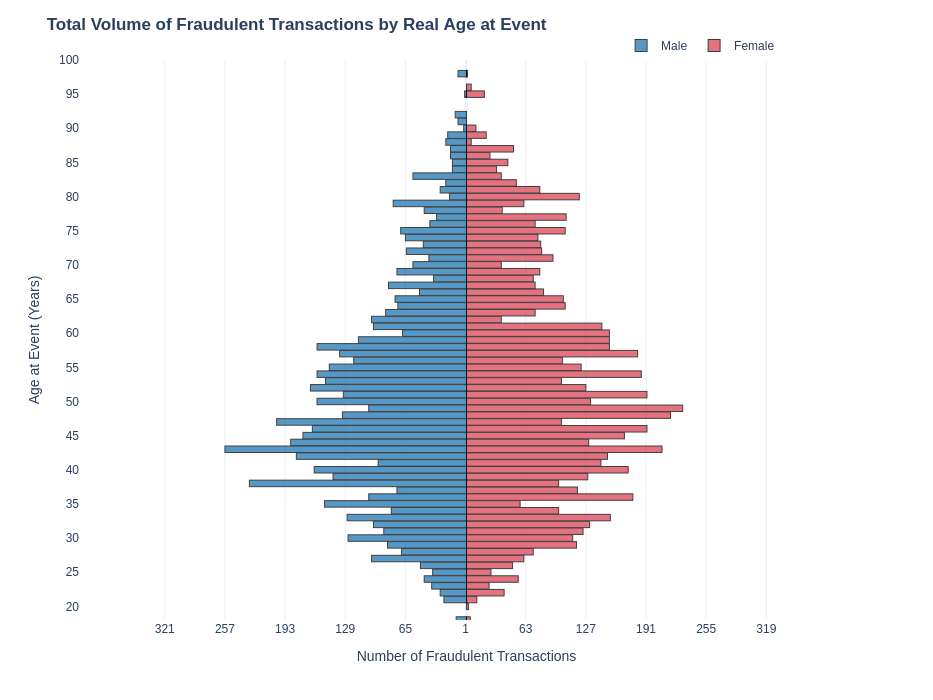

In [144]:
demographic_fraud_age_pd = demographic_fraud_age_df.collect()

demographic_fraud_age_fig = px.bar(
    demographic_fraud_age_pd,
    x="Total_pyramid",
    y="age_at_transaction",
    color="gender",  
    orientation="h",
    color_discrete_map={"Male": "#1F77B4", "Female": "#DB4455"},
    custom_data=["Total"]
)

demographic_fraud_age_fig.update_traces(
    opacity=0.75, marker_line_width=1., marker_line_color="#000000",
    hovertemplate="<b>Age: %{y} years old</b><br>Fraudulent Transactions: %{customdata[0]:,}<extra></extra>"
)

max_count = int(demographic_fraud_age_pd["Total"].max())
tick_step = max(1, max_count // 4)
tick_vals = list(range(-max_count - tick_step, max_count + tick_step, tick_step))
tick_text = [str(abs(v)) for v in tick_vals]

demographic_fraud_age_fig.update_layout(
    title="<b>Total Volume of Fraudulent Transactions by Real Age at Event</b>",
    barmode="overlay", bargap=0.05, 
    height=700, width=950, autosize=False,    
    legend=dict(orientation="h", yanchor="bottom", y=1.0, xanchor="left", x=0.7, title=None),
    xaxis=dict(
        title="Number of Fraudulent Transactions",
        tickvals=tick_vals, ticktext=tick_text, 
        range=[-max_count * 1.6, max_count * 1.6]
    ),
    yaxis=dict(title="Age at Event (Years)", type="linear", range=[18, 100], dtick=5),
    template="plotly_white",
)

demographic_fraud_age_fig.show()


In [119]:
demographic_transaction_age_df = (
    fraud_data_df       
    .filter(pl.col("target").is_not_null())
    .with_columns(
        age_at_event = pl.col("date").dt.year() - pl.col("birth_year")
    )     
    .pivot(
        on="target",  index=["age_at_event", "gender"], 
        values="target", aggregate_function="len", 
        on_columns = [False, True]
    )
    .rename({"false": "Legitimate", "true": "Fraudulent"})
    .with_columns(
        frd_leg_ratio = (pl.col("Fraudulent")/(pl.col("Legitimate") + 1)).round(5)
    )
    .with_columns(
        ratio_pyramid = (
            pl.when(pl.col("gender") == "Male")
                .then(pl.col("frd_leg_ratio") * -1)
                .otherwise(pl.col("frd_leg_ratio"))
        )
    )  
)

demographic_transaction_age_df.show(5)

age_at_event,gender,Legitimate,Fraudulent,frd_leg_ratio,ratio_pyramid
i64,cat,u32,u32,f64,f64
36,"""Male""",99083,104,0.00105,-0.00105
47,"""Female""",112573,101,0.0009,0.0009
33,"""Female""",83145,153,0.00184,0.00184
58,"""Female""",80652,152,0.00188,0.00188
37,"""Male""",93704,74,0.00079,-0.00079


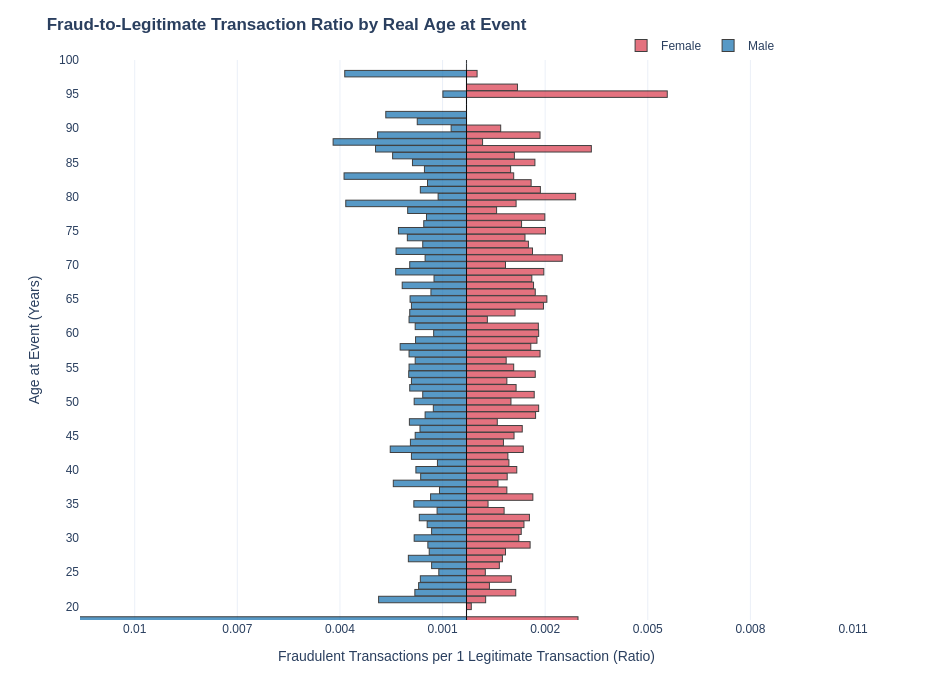

In [145]:
demographic_transaction_age_pd = demographic_transaction_age_df.collect()

demographic_transaction_age_fig = px.bar(
    demographic_transaction_age_pd,
    x="ratio_pyramid",
    y="age_at_event",
    color="gender", 
    orientation="h",
    color_discrete_map={"Male": "#1F77B4", "Female": "#DB4455"},
    custom_data=["Legitimate", "Fraudulent", "frd_leg_ratio"],
)

demographic_transaction_age_fig.update_traces(
    opacity=0.75, marker_line_width=1., marker_line_color="#000000",
    hovertemplate="<b>Age at Event: %{y} years old</b><br>" +
                  "Fraud Ratio: %{customdata[2]:.4f}<br>" +
                  "Fraudulent Transactions: %{customdata[1]:,}<br>" +
                  "Legitimate Transactions: %{customdata[0]:,}<extra></extra>"
)

max_ratio = demographic_transaction_age_pd["frd_leg_ratio"].max()
tick_step = max(0.001, round(max_ratio / 4, 3))

tick_vals = []
val = -max_ratio
while val <= max_ratio:
    tick_vals.append(round(val, 4))
    val += tick_step
tick_text = [str(abs(round(v, 3))) for v in tick_vals]
limite_eje_x = abs(tick_vals[-1])

demographic_transaction_age_fig.update_layout(
    title="<b>Fraud-to-Legitimate Transaction Ratio by Real Age at Event</b>",
    barmode="overlay", bargap=0.05, 
    height=700, width=900, autosize=False,    
    legend=dict(orientation="h", yanchor="bottom", y=1.0, xanchor="left", x=0.7, title=None),
    xaxis=dict(
        title="Fraudulent Transactions per 1 Legitimate Transaction (Ratio)", 
        tickvals=tick_vals, ticktext=tick_text, 
        range=[-limite_eje_x, limite_eje_x]
    ),
    yaxis=dict(title="Age at Event (Years)", type="linear", range=[18, 100], dtick=5),
    template="plotly_white",
)

demographic_transaction_age_fig.show()


In [21]:
mcc_description_df = (
    fraud_data_df
    .filter(pl.col("target").is_not_null())
    .pivot(
        on="target", index="mcc_description", 
        values="mcc_description", aggregate_function="len",
        on_columns=["false", "true"], 
    )
    .rename({"false": "Legitimate", "true": "Fraudulent"})
    .with_columns(
        mcc_rate = pl.col("Fraudulent")/(pl.col("Legitimate") + 1)
    )
    .with_columns(
        total_leg = pl.col("Legitimate").sum(),
        total_fraud = pl.col("Fraudulent").sum()
    )
    .with_columns(
        fraud_rate = pl.col("total_fraud")/pl.col("total_leg")
    )
    .with_columns(
        mcc_risk_factor = pl.col("mcc_rate")/pl.col("fraud_rate")
    )
    .with_columns(
        Log2_risk_factor = (pl.col("mcc_risk_factor") + 0.00001).log(base=2).round(2)
    )  
    .with_columns(
        mcc_risk_category = (
            pl.when(pl.col("Log2_risk_factor") > 2).then(pl.lit("High Risk"))
                .when(pl.col("Log2_risk_factor") < -2).then(pl.lit("Low Risk"))
                .otherwise(pl.lit("Baseline Risk"))
        )
    ) 
    .drop(["total_leg", "total_fraud", "fraud_rate", "mcc_rate"])
)

mcc_description_df.show(5)

mcc_description,Legitimate,Fraudulent,mcc_risk_factor,Log2_risk_factor,mcc_risk_category
str,u32,u32,f64,f64,str
"""Leather Goods""",1879,16,5.68246,2.51,"""High Risk"""
"""Fast Food Restaurants""",334098,235,0.469642,-1.09,"""Baseline Risk"""
"""Athletic Fields, Commercial Sp…",11714,84,4.787527,2.26,"""High Risk"""
"""Insurance Sales, Underwriting""",34196,0,0.0,-16.61,"""Low Risk"""
"""Accounting, Auditing, and Book…",2354,0,0.0,-16.61,"""Low Risk"""


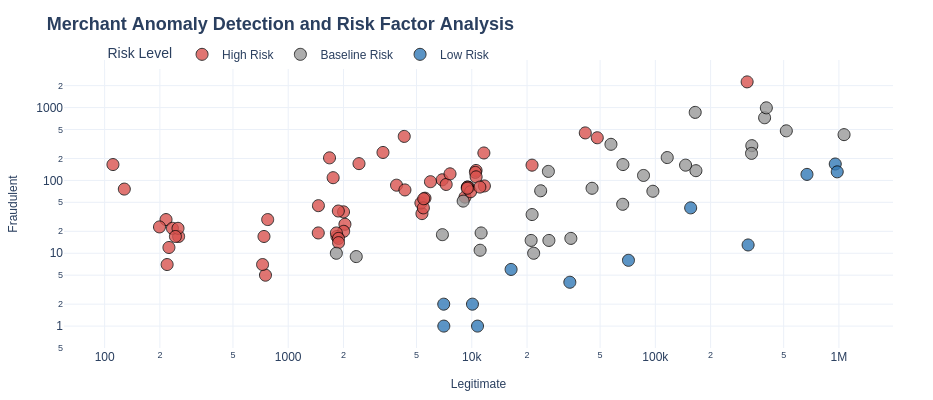

In [133]:
mcc_description_mem = mcc_description_df.collect()

color_risk = {
    'High Risk': '#d9534f',      
    'Baseline Risk': '#999999',  
    'Low Risk': '#337ab7'      
}

mcc_fig = px.scatter(
    mcc_description_mem,
    x="Legitimate",
    y="Fraudulent",
    color="mcc_risk_category",   
    color_discrete_map=color_risk,    
    hover_name="mcc_description", 
    hover_data=["Legitimate", "Fraudulent", "mcc_risk_factor", "Log2_risk_factor"],
    log_x=True,                   
    log_y=True,                  
    title="<b>Merchant Anomaly Detection and Risk Factor Analysis</b>",
    labels={"mcc_risk_category": "Risk Level", "mcc_risk_factor": "Risk Factor",
           "Log2_risk_factor": "Log2(Risk Factor)"},
    template="plotly_white"   
)


mcc_fig.update_traces(
    marker=dict(
        size=12,
        line=dict(width=1, color='Black'),
        opacity=0.8
    )
)

mcc_fig.update_layout(
    height=400, width=900, autosize=False,
    title_font_size=18, xaxis_title_font_size=12, yaxis_title_font_size=12,
    margin=dict(l=40, r=40, t=60, b=40),
    legend=dict(orientation="h", yanchor="top", y=1.07, xanchor="left", x=0.05)
)

mcc_fig.show()

In [5]:
fraud_data_df = (
    pl.scan_parquet(f"{path}complete_fraud_data.parquet")
    .select("errors")
)
with pl.Config(tbl_rows=-1, fmt_str_lengths=100):
    print(fraud_data_df.unique().collect())

shape: (23, 1)
┌─────────────────────────────────────────────────────┐
│ errors                                              │
│ ---                                                 │
│ cat                                                 │
╞═════════════════════════════════════════════════════╡
│ null                                                │
│ Bad Zipcode,Technical Glitch                        │
│ Bad Card Number,Insufficient Balance                │
│ Bad PIN,Insufficient Balance                        │
│ Bad Card Number                                     │
│ Insufficient Balance                                │
│ Bad Card Number,Technical Glitch                    │
│ Bad CVV,Technical Glitch                            │
│ Bad Card Number,Bad Expiration                      │
│ Bad Expiration,Technical Glitch                     │
│ Bad Expiration,Insufficient Balance                 │
│ Bad CVV                                             │
│ Bad Zipcode                    

In [6]:
fraud_data_df = (
    pl.scan_parquet(f"{path}complete_fraud_data.parquet")
    .select("card_brand")
)
with pl.Config(tbl_rows=-1, fmt_str_lengths=100):
    print(fraud_data_df.unique().collect())

shape: (4, 1)
┌────────────┐
│ card_brand │
│ ---        │
│ cat        │
╞════════════╡
│ Visa       │
│ Discover   │
│ Amex       │
│ Mastercard │
└────────────┘


In [7]:
fraud_data_df = (
    pl.scan_parquet(f"{path}complete_fraud_data.parquet")
    .select("card_type")
)
with pl.Config(tbl_rows=-1, fmt_str_lengths=100):
    print(fraud_data_df.unique().collect())

shape: (3, 1)
┌─────────────────┐
│ card_type       │
│ ---             │
│ cat             │
╞═════════════════╡
│ Debit (Prepaid) │
│ Credit          │
│ Debit           │
└─────────────────┘


In [8]:
fraud_data_df = (
    pl.scan_parquet(f"{path}complete_fraud_data.parquet")
    .select("use_chip")
)
with pl.Config(tbl_rows=-1, fmt_str_lengths=100):
    print(fraud_data_df.unique().collect())

shape: (3, 1)
┌────────────────────┐
│ use_chip           │
│ ---                │
│ cat                │
╞════════════════════╡
│ Online Transaction │
│ Chip Transaction   │
│ Swipe Transaction  │
└────────────────────┘


In [16]:
fraud_data_df = (
    pl.scan_parquet(f"{path}complete_fraud_data.parquet")
    .select("retirement_age")
)
with pl.Config(tbl_rows=-1, fmt_str_lengths=100):
    print(fraud_data_df.unique().collect())

shape: (27, 1)
┌────────────────┐
│ retirement_age │
│ ---            │
│ i64            │
╞════════════════╡
│ 54             │
│ 60             │
│ 63             │
│ 57             │
│ 78             │
│ 69             │
│ 66             │
│ 75             │
│ 72             │
│ 61             │
│ 55             │
│ 58             │
│ 64             │
│ 76             │
│ 73             │
│ 70             │
│ 67             │
│ 79             │
│ 65             │
│ 62             │
│ 53             │
│ 56             │
│ 59             │
│ 77             │
│ 71             │
│ 74             │
│ 68             │
└────────────────┘
